<a href="https://colab.research.google.com/github/fatazeouedraogo/Deep-Learning-for-Healthcare-Brain-Tumor-Classification-using-VGG16/blob/main/New_article_classification_CNN_Deep_Learning_Proeject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DEEP LEARNING PROJECT: NEWS ARTICLE CLASSIFICATION USING CONVOLUTIONAL NEURAL NETWORKS

ENVIRONMENT SETUP

In [2]:
print("\nInstalling required libraries...")

# Install packages
!pip install -q kaggle tensorflow opencv-python-headless pillow matplotlib seaborn scikit-learn

print("Libraries installed successfully!")


Installing required libraries...
Libraries installed successfully!


# IMPORT LIBRARIES

In [3]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import random
import json
import shutil
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print("All libraries imported successfully!")

TensorFlow version: 2.19.0
Keras version: 3.10.0
All libraries imported successfully!


# MOUNT GOOGLE DRIVE

In [4]:

print("\nMounting Google Drive...")

from google.colab import drive
drive.mount('/content/drive')

project_folder = '/content/drive/MyDrive/DeepLearning_Project'
os.makedirs(project_folder, exist_ok=True)

print(f"Google Drive mounted successfully!")
print(f"Project folder: {project_folder}")


Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully!
Project folder: /content/drive/MyDrive/DeepLearning_Project


#UPLOAD KAGGLE API KEY

In [6]:
from google.colab import files
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully!")

Saving kaggle.json to kaggle.json
Kaggle API configured successfully!


In [7]:
# ==============================================================================
# SECTION 5: DOWNLOAD DATASET FROM KAGGLE
# ==============================================================================

print("\nDownloading CNN/Daily Mail dataset from Kaggle...")

!kaggle datasets download -d gowrishankarp/newspaper-text-summarization-cnn-dailymail

!unzip -q newspaper-text-summarization-cnn-dailymail.zip -d /content/dataset

print("Dataset downloaded and extracted successfully!")
print("\nDataset contents:")
!ls -lh /content/dataset


Dataset URL: https://www.kaggle.com/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail
License(s): CC0-1.0
 97% 490M/503M [00:05<00:00, 129MB/s]
100% 503M/503M [00:05<00:00, 103MB/s]
Dataset downloaded and extracted successfully!

Dataset contents:
total 4.0K
drwxr-xr-x 2 root root 4.0K Jan 25 14:03 cnn_dailymail


# LOAD AND EXPLORE DATASET

In [14]:
# ==============================================================================
# SECTION 6: LOAD AND EXPLORE DATASET (CORRECTED)
# ==============================================================================

print("\nLoading dataset...")

# First, let's see what files we have
print("Files in /content/:")
!ls -lh /content/

# The dataset might still be zipped, let's unzip it properly
import zipfile

zip_file = '/content/newspaper-text-summarization-cnn-dailymail.zip'

# Check if zip file exists
if os.path.exists(zip_file):
    print(f"\nFound zip file: {zip_file}")
    print("Extracting...")

    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset')

    print("Extraction complete!")
else:
    print("Zip file not found. Checking /content/dataset...")

# Now check what's in the dataset folder
print("\nContents of /content/dataset:")
!ls -lh /content/dataset/

# Find all files recursively
print("\nAll files in dataset (recursive):")
for root, dirs, files in os.walk('/content/dataset'):
    for file in files:
        print(os.path.join(root, file))

# Look for CSV or text files
dataset_path = '/content/dataset'
all_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.csv', '.txt', '.json')):
            all_files.append(os.path.join(root, file))

print(f"\nFound {len(all_files)} data files:")
for f in all_files:
    print(f"  - {f}")

# Load the first CSV file found
if all_files:
    data_file = all_files[0]
    print(f"\nLoading file: {data_file}")

    # Try to load based on file extension
    if data_file.endswith('.csv'):
        df = pd.read_csv(data_file)
    elif data_file.endswith('.json'):
        df = pd.read_json(data_file)
    elif data_file.endswith('.txt'):
        # Read as text file
        with open(data_file, 'r') as f:
            lines = f.readlines()
        print(f"Text file with {len(lines)} lines")
        # You may need to parse this differently

    print("\nDataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nFirst few rows:")
    print(df.head())

else:
    print("\nNo CSV/JSON/TXT files found. Let's check the structure:")
    !find /content/dataset -type f | head -20


Loading dataset...
Files in /content/:
total 504M
drwxr-xr-x 3 root root 4.0K Jan 25 14:03 dataset
drwx------ 5 root root 4.0K Jan 25 13:49 drive
-rw-r--r-- 1 root root   71 Jan 25 14:02 kaggle.json
-rw-r--r-- 1 root root 504M Oct 23  2021 newspaper-text-summarization-cnn-dailymail.zip
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data

Found zip file: /content/newspaper-text-summarization-cnn-dailymail.zip
Extracting...
Extraction complete!

Contents of /content/dataset:
total 4.0K
drwxr-xr-x 2 root root 4.0K Jan 25 14:03 cnn_dailymail

All files in dataset (recursive):
/content/dataset/cnn_dailymail/validation.csv
/content/dataset/cnn_dailymail/train.csv
/content/dataset/cnn_dailymail/test.csv

Found 3 data files:
  - /content/dataset/cnn_dailymail/validation.csv
  - /content/dataset/cnn_dailymail/train.csv
  - /content/dataset/cnn_dailymail/test.csv

Loading file: /content/dataset/cnn_dailymail/validation.csv

Dataset loaded successfully!
Dataset shape: (13368, 3)

Columns: ['id'

# DATA PREPROCESSING

In [15]:



# Check column names and adjust accordingly
print(f"Available columns: {df.columns.tolist()}")

# Assuming columns are 'article' and 'highlights' or similar
# Adjust based on actual column names
if 'article' in df.columns and 'highlights' in df.columns:
    df = df[['article', 'highlights']].copy()
    df.columns = ['text', 'summary']
else:
    # Use first two text columns
    text_cols = df.select_dtypes(include=['object']).columns.tolist()
    if len(text_cols) >= 2:
        df = df[[text_cols[0], text_cols[1]]].copy()
        df.columns = ['text', 'summary']

# Remove missing values
df = df.dropna()


# This is a workaround since we don't have image data
def categorize_article(text):
    """Categorize articles based on keywords"""
    text_lower = str(text).lower()

    if any(word in text_lower for word in ['trump', 'president', 'election', 'government', 'political']):
        return 'Politics'
    elif any(word in text_lower for word in ['economy', 'business', 'market', 'company', 'stock']):
        return 'Business'
    elif any(word in text_lower for word in ['sport', 'game', 'player', 'team', 'football', 'basketball']):
        return 'Sports'
    elif any(word in text_lower for word in ['movie', 'music', 'celebrity', 'entertainment', 'actor']):
        return 'Entertainment'
    elif any(word in text_lower for word in ['technology', 'tech', 'software', 'computer', 'digital']):
        return 'Technology'
    else:
        return 'World News'

df['category'] = df['text'].apply(categorize_article)

print(f"\nDataset after preprocessing: {df.shape}")
print(f"\nCategory distribution:")
print(df['category'].value_counts())

# Save preprocessed data
df.to_csv(f'{project_folder}/preprocessed_data.csv', index=False)
print("\nPreprocessed data saved to Google Drive!")

Available columns: ['id', 'article', 'highlights']

Dataset after preprocessing: (13368, 3)

Category distribution:
category
Sports           4178
Politics         3132
World News       2943
Business         2294
Entertainment     548
Technology        273
Name: count, dtype: int64

Preprocessed data saved to Google Drive!


# VISUALIZE DATA DISTRIBUTION


Visualizing data distribution...


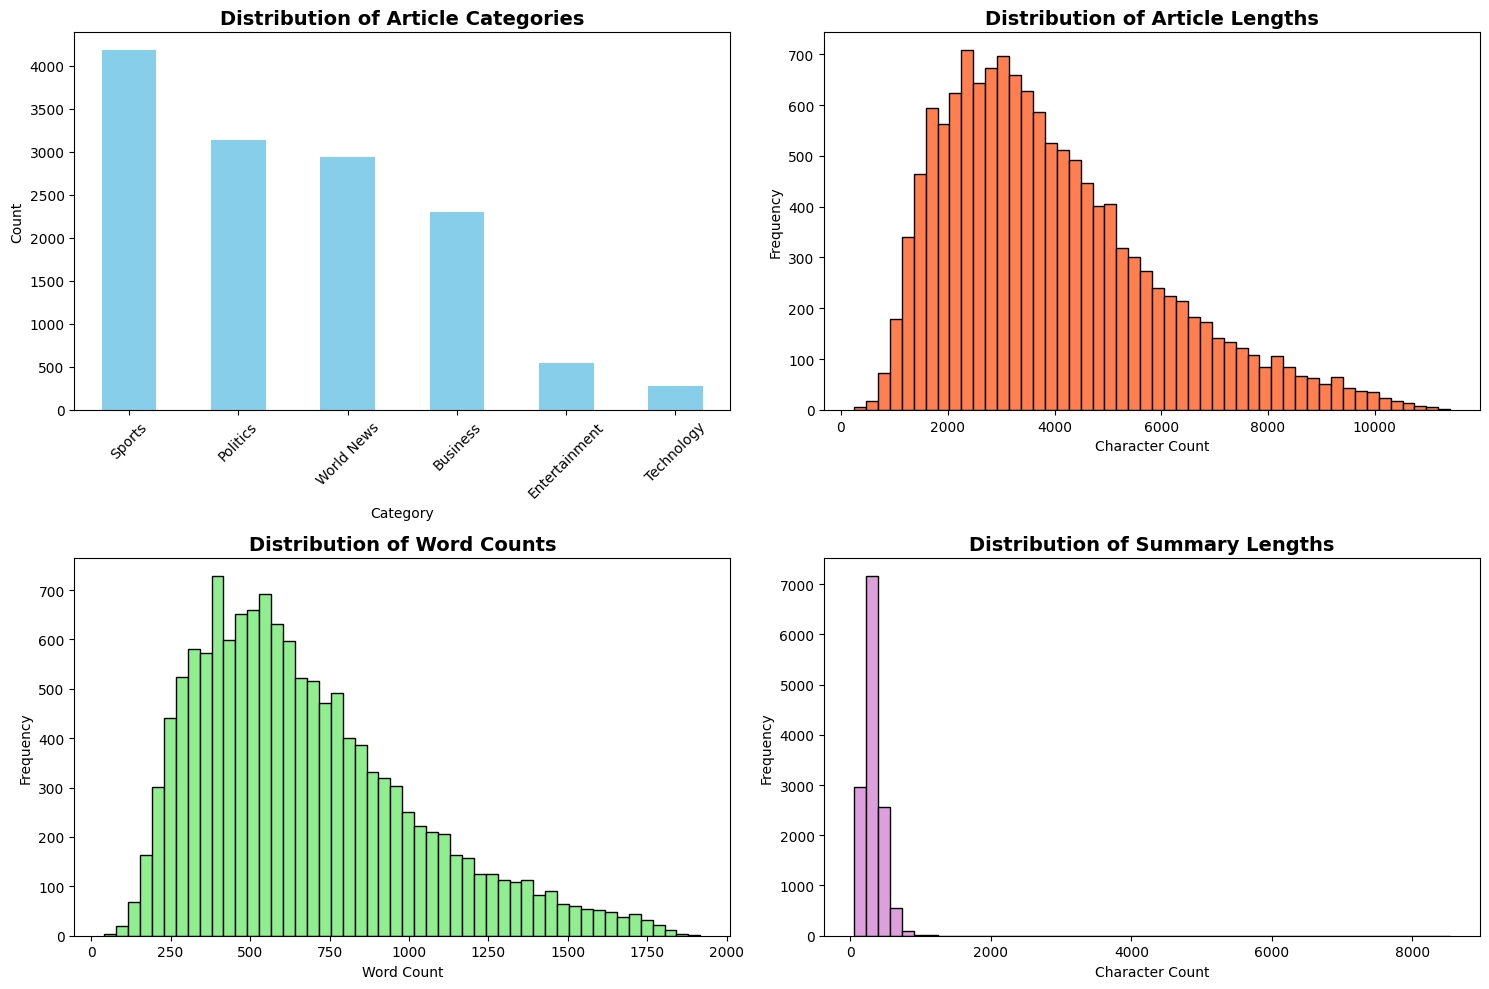

Data distribution plots saved to Google Drive!


In [16]:

print("\nVisualizing data distribution...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Category distribution
ax1 = axes[0, 0]
df['category'].value_counts().plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Distribution of Article Categories', fontsize=14, fontweight='bold')
ax1.set_xlabel('Category')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Article length distribution
ax2 = axes[0, 1]
df['text_length'] = df['text'].str.len()
ax2.hist(df['text_length'], bins=50, color='coral', edgecolor='black')
ax2.set_title('Distribution of Article Lengths', fontsize=14, fontweight='bold')
ax2.set_xlabel('Character Count')
ax2.set_ylabel('Frequency')

# Word count distribution
ax3 = axes[1, 0]
df['word_count'] = df['text'].str.split().str.len()
ax3.hist(df['word_count'], bins=50, color='lightgreen', edgecolor='black')
ax3.set_title('Distribution of Word Counts', fontsize=14, fontweight='bold')
ax3.set_xlabel('Word Count')
ax3.set_ylabel('Frequency')

# Summary length distribution
ax4 = axes[1, 1]
df['summary_length'] = df['summary'].str.len()
ax4.hist(df['summary_length'], bins=50, color='plum', edgecolor='black')
ax4.set_title('Distribution of Summary Lengths', fontsize=14, fontweight='bold')
ax4.set_xlabel('Character Count')
ax4.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(f'{project_folder}/data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Data distribution plots saved to Google Drive!")

# GENERATE WORD CLOUDS FOR EACH CATEGORY


Generating word clouds for each category...


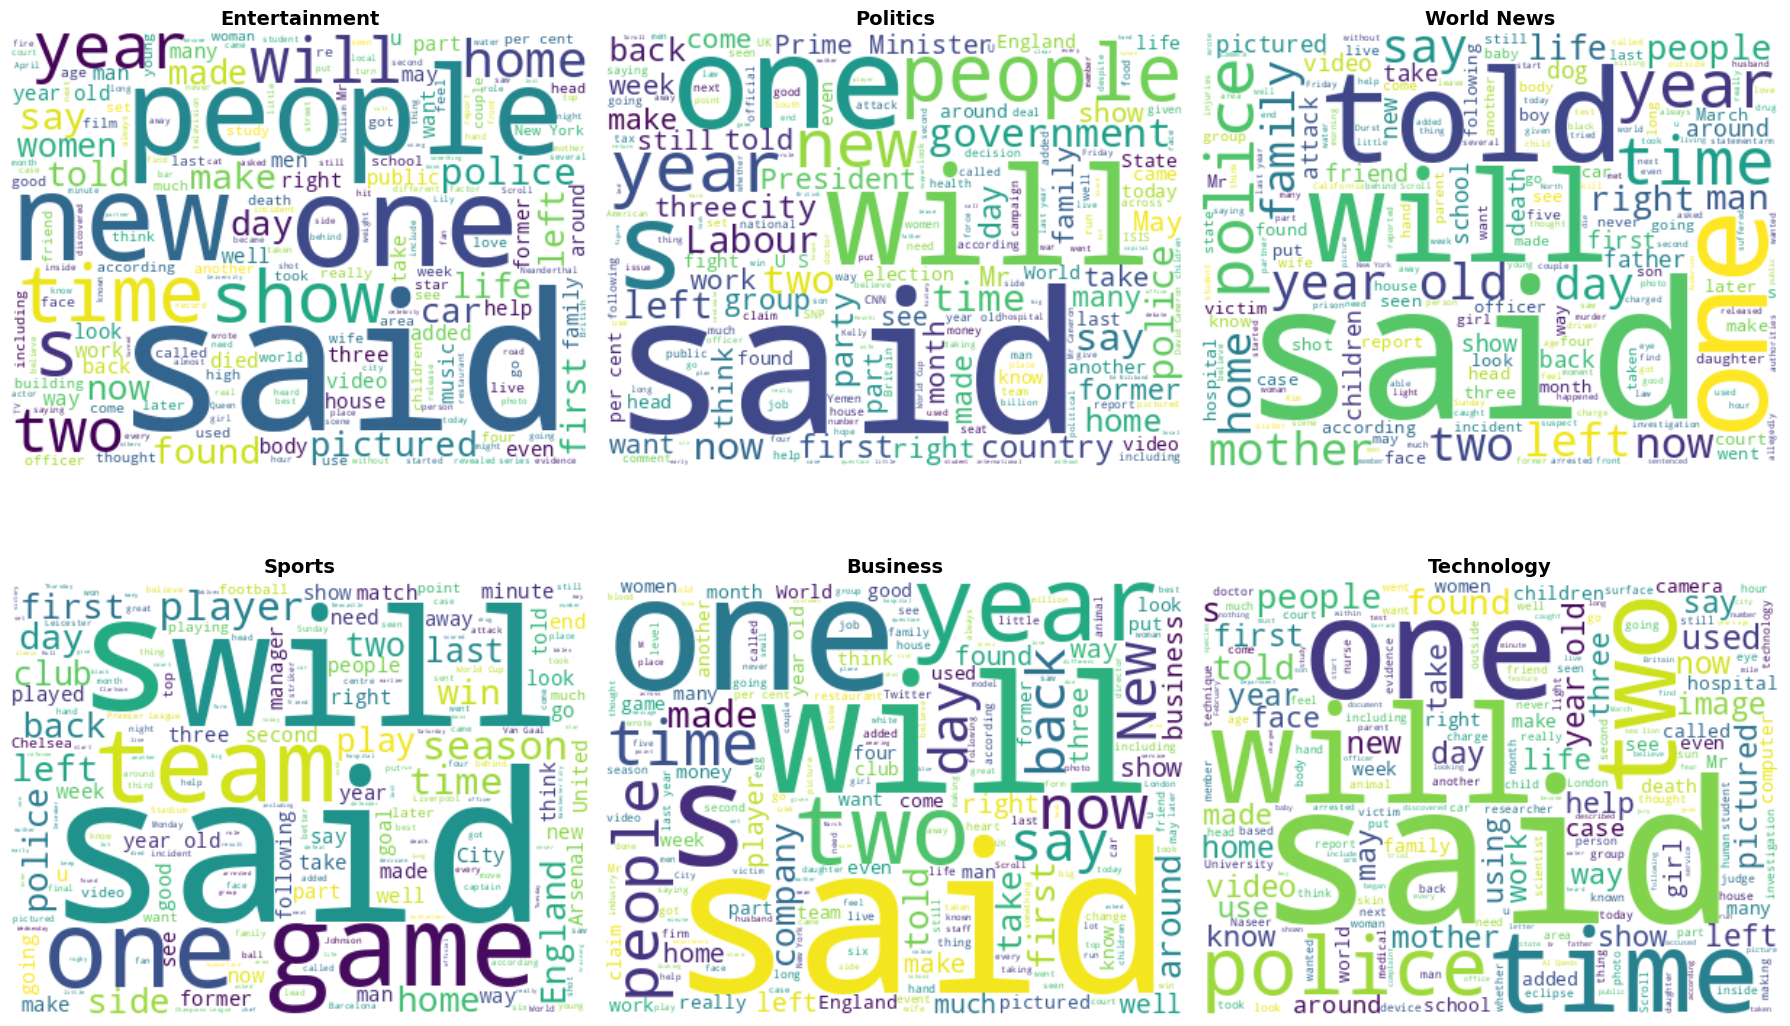

Word clouds saved to Google Drive!


In [18]:

print("\nGenerating word clouds for each category...")
from wordcloud import WordCloud

categories = df['category'].unique()
n_categories = len(categories)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, category in enumerate(categories):
    if idx < len(axes):
        text = ' '.join(df[df['category'] == category]['text'].head(100))

        wordcloud = WordCloud(width=400, height=300,
                             background_color='white',
                             colormap='viridis').generate(text)

        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f'{category}', fontsize=14, fontweight='bold')
        axes[idx].axis('off')

# Hide extra subplots
for idx in range(n_categories, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f'{project_folder}/word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

print("Word clouds saved to Google Drive!")

# PREPARE DATA FOR NEURAL NETWORK

In [23]:

print("\nPreparing data for neural network...")

# Import necessary modules
import re
import pickle
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Encode categories
label_encoder = LabelEncoder()
df['category_encoded'] = label_encoder.fit_transform(df['category'])

num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_.tolist()

print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# Limit dataset size for faster training
sample_size = min(10000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

# Text preprocessing
def clean_text(text):
    """Clean and preprocess text"""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df_sample['text_clean'] = df_sample['text'].apply(clean_text)

# Tokenization
MAX_WORDS = 10000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df_sample['text_clean'])

sequences = tokenizer.texts_to_sequences(df_sample['text_clean'])
padded_sequences = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Prepare labels
y = keras.utils.to_categorical(df_sample['category_encoded'], num_classes)

# Train-validation-test split
X_temp, X_test, y_temp, y_test = train_test_split(
    padded_sequences, y, test_size=0.15, random_state=42, stratify=df_sample['category_encoded']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp.argmax(axis=1)
)

print(f"\nData split:")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# Save tokenizer
with open(f'{project_folder}/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("\nTokenizer saved to Google Drive!")


Preparing data for neural network...
Number of classes: 6
Classes: ['Business', 'Entertainment', 'Politics', 'Sports', 'Technology', 'World News']

Data split:
Training samples: 7004
Validation samples: 1496
Test samples: 1500

Tokenizer saved to Google Drive!


# BUILDING of  NEURAL NETWORK MODEL

In [25]:


print("\nBuilding Neural Network model...")

def create_text_classification_model(vocab_size, embedding_dim, max_length, num_classes):
    """
    Create a neural network for text classification
    Uses embedding + CNN layers as specified in project requirements
    """

    model = models.Sequential([
        # Embedding layer
        layers.Embedding(vocab_size, embedding_dim, input_length=max_length),

        # CNN LAYER 1
        layers.Conv1D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling1D(2),

        # CNN LAYER 2
        layers.Conv1D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling1D(2),

        # Flatten
        layers.Flatten(),

        # FULLY CONNECTED LAYER 1
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        # OUTPUT LAYER
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create model
EMBEDDING_DIM = 128

model = create_text_classification_model(
    vocab_size=MAX_WORDS,
    embedding_dim=EMBEDDING_DIM,
    max_length=MAX_LEN,
    num_classes=num_classes
)

# Build the model
model.build(input_shape=(None, MAX_LEN))

# Display model summary
model.summary()

# Save model architecture
try:
    plot_model(model, to_file=f'{project_folder}/model_architecture.png',
               show_shapes=True, show_layer_names=True)
    print("\nModel architecture saved to Google Drive!")
except Exception as e:
    print(f"\nNote: Could not save architecture diagram: {e}")
    print("This is not critical - continuing with training...")


Building Neural Network model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 32)        │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,940,518 (11.22 MB)

 Trainable params: 2,940,518 (11.22 MB)

 Non-trainable params: 0 (0.00 B)


Model architecture saved to Google Drive!


# COMPILE MODEL

In [27]:

print("\nCompiling model...")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print("\nHyperparameters:")
print(f"  Optimizer: Adam")
print(f"  Learning Rate: 0.001")
print(f"  Loss Function: Categorical Cross-Entropy")
print(f"  Batch Size: 32")
print(f"  Max Sequence Length: {MAX_LEN}")
print(f"  Embedding Dimension: {EMBEDDING_DIM}")


Compiling model...
Model compiled successfully!

Hyperparameters:
  Optimizer: Adam
  Learning Rate: 0.001
  Loss Function: Categorical Cross-Entropy
  Batch Size: 32
  Max Sequence Length: 200
  Embedding Dimension: 128


# SETUP CALLBACKS

In [28]:

print("\nSetting up training callbacks...")

checkpoint_path = f'{project_folder}/best_model.h5'

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured successfully!")


Setting up training callbacks...
Callbacks configured successfully!


# MODEL TRAINING

In [29]:

print("\nStarting model training...")
print("=" * 80)

EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 80)
print("Training completed successfully!")


Starting model training...
Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3552 - loss: 1.4921
Epoch 1: val_accuracy improved from -inf to 0.56417, saving model to /content/drive/MyDrive/DeepLearning_Project/best_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.3555 - loss: 1.4915 - val_accuracy: 0.5642 - val_loss: 1.1528 - learning_rate: 0.0010
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6143 - loss: 1.0232
Epoch 2: val_accuracy improved from 0.56417 to 0.56818, saving model to /content/drive/MyDrive/DeepLearning_Project/best_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.6144 - loss: 1.0232 - val_accuracy: 0.5682 - val_loss: 1.1419 - learning_rate: 0.0010
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7619 - loss: 0.6807
Epoch 3: val_accuracy improved from 0.56818 to 0.58088, saving model to /content/drive/MyDrive/DeepLearning_Project/best_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - accuracy: 0.7619 - loss: 0.6807 - val_accuracy: 0.5809 - val_loss: 1.3185 - learning_rate: 0.0010
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8936 - loss: 0.3215
Epoch 4: val_accuracy did not improve from 0.58088
219/219 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.8935 - loss: 0.3215 - val_accuracy: 0.5401 - val_loss: 1.8310 - learning_rate: 0.0010
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9497 - loss: 0.1533
Epoch 5: val_accuracy did not improve from 0.58088

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9497 - loss: 0.1533 - val_accuracy: 0.5662 - val_loss: 2.1358 - learning_rate: 0.0010
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9875 - loss: 0.0544
Epoch 6: val_accuracy did not improve from 0.58088
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.9875 - loss: 0.0543 - v

# SAVE TRAINING HISTORY

In [30]:
print("\nSaving training history...")

history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}

with open(f'{project_folder}/training_history.json', 'w') as f:
    json.dump(history_dict, f, indent=4)

history_df = pd.DataFrame(history_dict)
history_df.to_csv(f'{project_folder}/training_history.csv', index=False)

print("Training history saved to Google Drive!")


Saving training history...
Training history saved to Google Drive!


# PLOT TRAINING CURVES


Generating training curves...


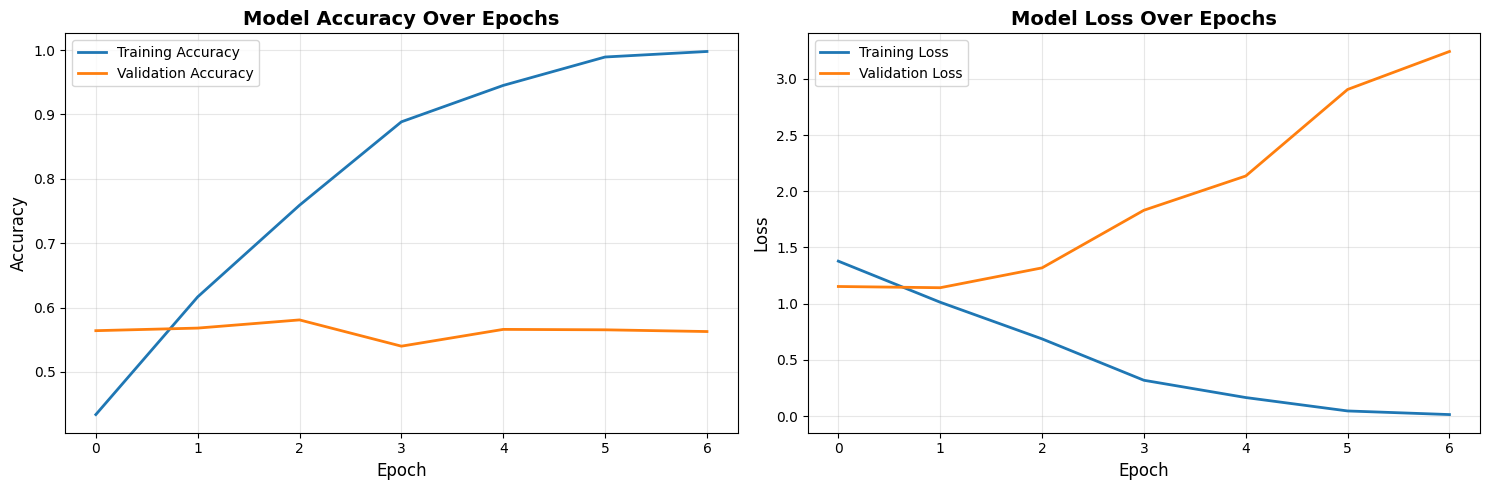

Training curves saved to Google Drive!


In [31]:

print("\nGenerating training curves...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{project_folder}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to Google Drive!")

# EVALUATE ON TEST SET

In [33]:

print("\nEvaluating model on test set...")
print("=" * 80)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("\n" + "=" * 80)
print(f"TEST RESULTS:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("=" * 80)

results = {
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy)
}

with open(f'{project_folder}/test_results.json', 'w') as f:
    json.dump(results, f, indent=4)




Evaluating model on test set...
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6011 - loss: 1.1121

TEST RESULTS:
  Test Loss: 1.1248
  Test Accuracy: 0.5840 (58.40%)


# CONFUSION MATRIX


Generating confusion matrix...
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step


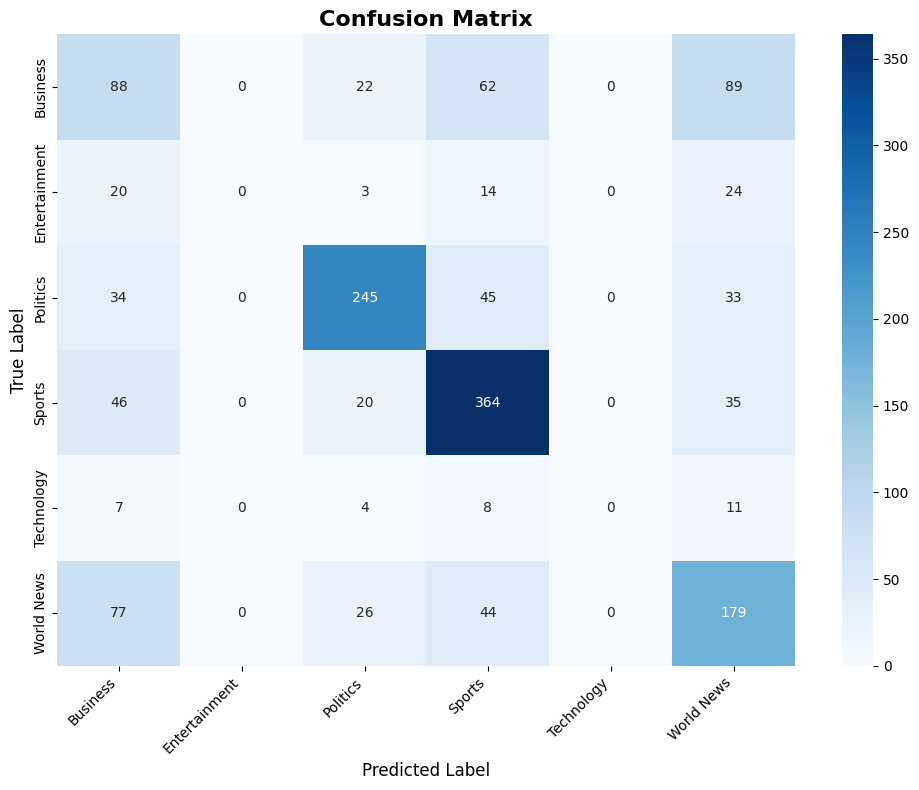

Confusion matrix saved to Google Drive!


In [35]:

print("\nGenerating confusion matrix...")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{project_folder}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved to Google Drive!")

In [36]:

#  CLASSIFICATION REPORT


print("\nGenerating classification report...")

report = classification_report(y_true_classes, y_pred_classes,
                               target_names=class_names, digits=4)

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT:")
print("=" * 80)
print(report)

with open(f'{project_folder}/classification_report.txt', 'w') as f:
    f.write("CLASSIFICATION REPORT\n")
    f.write("=" * 80 + "\n")
    f.write(report)

print("\nClassification report saved to Google Drive!")


Generating classification report...

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

     Business     0.3235    0.3372    0.3302       261
Entertainment     0.0000    0.0000    0.0000        61
     Politics     0.7656    0.6863    0.7238       357
       Sports     0.6778    0.7828    0.7265       465
   Technology     0.0000    0.0000    0.0000        30
   World News     0.4825    0.5491    0.5136       326

     accuracy                         0.5840      1500
    macro avg     0.3749    0.3926    0.3824      1500
 weighted avg     0.5535    0.5840    0.5666      1500


Classification report saved to Google Drive!


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# SAVE FINAL MODEL

In [39]:

print("\nSaving final trained model...")

model.save(f'{project_folder}/final_model.h5')
print("  1. Saved: final_model.h5")

# Save in Keras native format (recommended)
model.save(f'{project_folder}/final_model.keras')
print("  2. Saved: final_model.keras")


model.save_weights(f'{project_folder}/model_weights.weights.h5')
print("  3. Saved: model_weights.weights.h5")


model.export(f'{project_folder}/final_model_export')
print("  4. Saved: final_model_export/ (SavedModel format)")

print("\nAll model formats saved successfully!")
print("\nModel formats:")
print(f"  1. final_model.h5 - HDF5 format (legacy)")
print(f"  2. final_model.keras - Native Keras format (recommended)")
print(f"  3. model_weights.weights.h5 - Weights only")
print(f"  4. final_model_export/ - TensorFlow SavedModel for deployment")


Saving final trained model...
  1. Saved: final_model.h5
  2. Saved: final_model.keras
  3. Saved: model_weights.weights.h5
Saved artifact at '/content/drive/MyDrive/DeepLearning_Project/final_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  134848334758928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134848334758544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134848334761040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134848334759120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134848334759888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134848334757968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134848334760848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134848334760272: TensorSpec(shape=(), dtype=tf.resource, name

In [41]:

# SECTION 21: TEST PREDICTIONS ON SAMPLE TEXTS (CORRECTED)

print("\nTesting predictions on sample texts...")

def predict_text(text):
    """Predict category for a given text"""
    cleaned = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post')
    prediction = model.predict(padded, verbose=0)
    predicted_class_idx = np.argmax(prediction)
    confidence = prediction[0][predicted_class_idx]
    return class_names[predicted_class_idx], confidence * 100


test_size = len(X_test)
sample_count = min(5, test_size)

print("\n" + "=" * 80)
print("SAMPLE PREDICTIONS:")
print("=" * 80)


for i in range(sample_count):

    test_pred = model.predict(X_test[i:i+1], verbose=0)
    predicted_class_idx = np.argmax(test_pred)
    predicted_category = class_names[predicted_class_idx]
    confidence = test_pred[0][predicted_class_idx] * 100

    # Get true category
    true_class_idx = np.argmax(y_test[i])
    true_category = class_names[true_class_idx]


    try:

        category_samples = df_sample[df_sample['category'] == true_category]
        if len(category_samples) > 0:
            sample_row = category_samples.sample(1).iloc[0]
            text_sample = sample_row['text'][:200]
        else:
            text_sample = "[Text not available]"
    except:
        text_sample = "[Text not available]"

    print(f"\nSample {i+1}:")
    print(f"Text: {text_sample}...")
    print(f"True Category: {true_category}")
    print(f"Predicted Category: {predicted_category} ({confidence:.2f}%)")
    print("-" * 80)

print("\n" + "=" * 80)
print("Predictions completed!")
print("=" * 80)


Testing predictions on sample texts...

SAMPLE PREDICTIONS:

Sample 1:
Text: CIA Director John Brennan has ordered a sweeping overhaul of the spy agency, aimed in part at sharpening its focus on cyber operations and incorporating digital innovations into traditional intelligen...
True Category: Politics
Predicted Category: World News (36.46%)
--------------------------------------------------------------------------------

Sample 2:
Text: An Australian wildlife warrior has gone where most people would not dare by filming himself swimming alongside deadly saltwater crocodiles. Beau Greaves has tried to show off the 'sensitive side' of t...
True Category: World News
Predicted Category: Business (34.79%)
--------------------------------------------------------------------------------

Sample 3:
Text: Claims: Deanna Micoley has made the sensational allegation that Rosie O'Donnell knew her decision making was impaired by her heroin problem and therefore was unable to agree to giving up her